# Visual Classifier Evaluation
This notebook evaluates the `dima806/ai_vs_human_generated_image_detection` model on the test split of `julienlucas/midjourney-dalle-sd-nanobananapro-dataset`.

In [1]:
import torch
from datasets import load_dataset
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from visual_classifier import VisualClassifier, fine_tune_model

import warnings
warnings.filterwarnings('ignore')

import huggingface_hub
import os
huggingface_hub.login(token=os.environ.get('HF_TOKEN'))

## 1. Load the Dataset

In [2]:
dataset = load_dataset('julienlucas/midjourney-dalle-sd-nanobananapro-dataset')
test_dataset = dataset['test']
print(f"Loaded {len(test_dataset)} test examples.")

Loaded 2000 test examples.


## 2. Initialize the Model for Inference
We will initialize our custom `VisualClassifier` which loads the model and handles inference.

In [3]:
classifier = VisualClassifier(model_name_or_path="dima806/ai_vs_human_generated_image_detection")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Let's test it on a single image first:

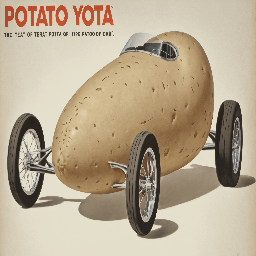

Ground Truth Label ID: 0
Prediction: {'prediction': 'Real', 'confidence': 0.9911, 'raw_label': 'human', 'all_scores': {'human': 0.9911, 'AI-generated': 0.0089}}


In [4]:
sample_image = test_dataset[0]['image']
sample_label = test_dataset[0]['label'] # Real/Human or Fake/AI label depending on dataset

display(sample_image.resize((256, 256)))
prediction = classifier.predict(sample_image)
print(f"Ground Truth Label ID: {sample_label}")
print(f"Prediction: {prediction}")

## 3. Evaluation on Test Set
We run the model on a subset (or full) test dataset and compute precision, recall, f1-score, etc.

In [5]:
true_labels = []
predicted_labels = []

# Update these based on the actual mapping in the dataset
label_map = {0: 'Real', 1: 'AI Generated'}

# Set a max sample limit if you want to evaluate faster
num_samples = len(test_dataset) 
# num_samples = 200 # uncomment for quick test

for i in tqdm(range(num_samples)):
    item = test_dataset[i]
    img = item['image']
    
    # Make sure to handle grayscale images by converting to RGB
    if img.mode != 'RGB':
        img = img.convert('RGB')
        
    true_label = label_map.get(item['label'], 'Unknown')
    
    pred_dict = classifier.predict(img)
    pred = pred_dict['prediction']
    
    true_labels.append(true_label)
    predicted_labels.append(pred)

  0%|          | 0/2000 [00:00<?, ?it/s]

In [6]:
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

print("\nConfusion Matrix (Fine-Tuned):")
print(confusion_matrix(true_labels, predicted_labels, labels=["Real", "AI Generated"]))

Classification Report:
              precision    recall  f1-score   support

AI Generated       0.19      0.01      0.02      1000
        Real       0.49      0.96      0.65      1000

    accuracy                           0.48      2000
   macro avg       0.34      0.48      0.33      2000
weighted avg       0.34      0.48      0.33      2000


Confusion Matrix (Fine-Tuned):
[[957  43]
 [990  10]]


## 4. Fine-Tuning (Optional)
If the model does not perform well enough, you can fine-tune it using the helper function. Note that fine-tuning requires significant time and memory. On your M4 MacBook, `mps` acceleration will be used automatically.

In [ ]:
model, processor = fine_tune_model()

## 5. Evaluation of Fine-Tuned Model
We now evaluate the fine-tuned model on the same test set to compare its performance.

In [ ]:
fine_tuned_classifier = VisualClassifier(model_name_or_path="./fine_tuned_model")

In [ ]:
ft_true_labels = []
ft_predicted_labels = []

for i in tqdm(range(num_samples)):
    item = test_dataset[i]
    img = item['image']
    
    if img.mode != 'RGB':
        img = img.convert('RGB')
        
    true_label = label_map.get(item['label'], 'Unknown')
    
    pred_dict = fine_tuned_classifier.predict(img)
    pred = pred_dict['prediction']
    
    ft_true_labels.append(true_label)
    ft_predicted_labels.append(pred)

In [ ]:
print("Classification Report (Fine-Tuned):")
print(classification_report(ft_true_labels, ft_predicted_labels))

print("\nConfusion Matrix (Fine-Tuned):")
print(confusion_matrix(ft_true_labels, ft_predicted_labels, labels=["Real", "AI Generated"]))